In [1]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 59.8 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.preprocessing import sequence
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from keras.layers import LSTM, Dense, SimpleRNN, Embedding, Flatten, Dropout
from keras.activations import softmax
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import StratifiedKFold

In [4]:
path = '/content/drive/MyDrive/SKRIPSI/fixed_final_dataset.csv'
df = pd.read_csv(path, delimiter=',')

df.head()

,created_at,full_text_processed,label
0,06/04/2025,anybodi need chip insert brain name fafo satan...,0
1,06/04/2025,pledg support justic digniti peac gaza join st...,0
2,06/04/2025,take posit gaza take posit gaza one live rest ...,0
3,06/04/2025,children gaza stand proof world look away dont...,0
4,06/04/2025,donat famili gaza struggl surviv war everi lit...,0


In [5]:
texts = df['full_text_processed'].tolist()
labels = df['label'].tolist()

In [6]:
import pickle

# Tokenisasi
tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)

with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

In [ ]:
# word2vec using fasttext
# tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
# tokenizer.fit_on_texts(texts)
# word_index = tokenizer.word_index

# import fasttext
# with open("corpus.txt", "w", encoding="utf-8") as f:
#     for t in texts:
#         f.write(t + "\n")

# ft_model = fasttext.train_unsupervised("corpus.txt", model='skipgram')

In [ ]:
# 3. Buat embedding matrix
# embedding_dim = ft_model.get_dimension()
# embedding_matrix = np.zeros((len(word_index)+1, embedding_dim))

# for word, i in word_index.items():
#     embedding_matrix[i] = ft_model.get_word_vector(word)

In [7]:
tokenized_texts = [text.split() for text in df['full_text_processed'].dropna()]

df.head()

,created_at,full_text_processed,label
0,06/04/2025,anybodi need chip insert brain name fafo satan...,0
1,06/04/2025,pledg support justic digniti peac gaza join st...,0
2,06/04/2025,take posit gaza take posit gaza one live rest ...,0
3,06/04/2025,children gaza stand proof world look away dont...,0
4,06/04/2025,donat famili gaza struggl surviv war everi lit...,0


In [8]:
# menghitung maxlen
maxlen = int(np.mean([len(x) for x in sequences]))

print(maxlen)

13


In [9]:
# Padding
maxlen = 13
X_padded = pad_sequences(sequences, maxlen=maxlen, padding='post')

In [10]:
from gensim.models import Word2Vec

embedding_dim = 100

w2v_model = Word2Vec(
    sentences=tokenized_texts,
    vector_size=embedding_dim,
    window=2,
    min_count=1,
    workers=4,
    epochs=25,
    sg=1
)

In [11]:
import numpy as np

num_words = 4171
embedding_matrix = np.zeros((num_words, embedding_dim))

word_index = tokenizer.word_index
for word, i in word_index.items():
    if i < num_words:
        if word in w2v_model.wv:
            embedding_matrix[i] = w2v_model.wv[word]

np.save("embedding_matrix.npy", embedding_matrix)
w2v_model.wv.save("word2vec_vectors.kv")
embedding_matrix = np.load("embedding_matrix.npy")
w2v_model.save("word2vec_full.model")
w2v_model.wv.save_word2vec_format("word2vec.txt", binary=False)

In [ ]:
w2v_model.wv.most_similar("genocide")

[('dark', 0.7439411282539368),
 ('debat', 0.729206383228302),
 ('journey', 0.7287983894348145),
 ('drc', 0.7276052236557007),
 ('survivor', 0.7223172187805176),
 ('honour', 0.721902072429657),
 ('rwanda', 0.7199408411979675),
 ('commit', 0.7152997851371765),
 ('reaffirm', 0.7131324410438538),
 ('larg', 0.710297703742981)]

In [ ]:
w2v_model.wv["genocide"]

array([-0.00644225, -0.24725096, -0.4566065 , -0.0929952 , -0.47336844,
       -0.7166264 ,  0.10910638,  0.19110526, -0.98267484, -0.5621204 ,
       -0.71474606, -0.13790764,  0.6358438 ,  0.42291155, -0.69411343,
        0.4602975 ,  0.5697233 ,  0.40399626, -0.34992632,  0.19886132,
        0.38827693,  0.56758016, -0.15824632,  0.5409326 , -0.3888687 ,
        0.8335994 ,  0.03749474,  0.39555478, -0.54260314,  0.3105899 ,
        0.01960889,  0.38604128, -0.7780204 ,  0.11915793, -0.34249943,
        0.09932802, -0.2677992 ,  0.00922106,  0.30306238, -0.51809204,
        0.02405942,  0.07015349,  0.7154606 ,  0.22710006,  0.90408075,
        0.21580195,  0.3597194 , -0.7098724 ,  0.29141492, -0.32932597],
      dtype=float32)

In [ ]:
# label_mapping = {'p': 2, 'n': 1, 'c': 0}
# df['label'] = df['label'].map(label_mapping)

# df.head()

In [ ]:
# Split data stratified
# X_train, X_test, y_train, y_test = train_test_split(
#     X_padded, labels, test_size=0.2, stratify=labels, random_state=42
# )

In [12]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

le = LabelEncoder()
labels = le.fit_transform(labels)
labels = np.array(labels)

Data Split pakai Kfold

In [13]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

n_splits = 10
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

In [14]:
vocab_size = len(tokenizer.word_index) + 1

print(vocab_size)

4171


In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SpatialDropout1D, LSTM, Flatten, Dense
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


fold = 1
results = []

for train_index, val_index in skf.split(X_padded, labels):
    print(f"\nFold {fold} -------------------------")

    X_train, X_val = X_padded[train_index], X_padded[val_index]
    y_train, y_val = labels[train_index], labels[val_index]

    model = Sequential()
    model.add(Embedding(input_dim=vocab_size,
                        output_dim=100,
                        weights=[embedding_matrix],
                        input_length=100))
    model.add(LSTM(32, dropout=0.2, recurrent_dropout=0.2))
    model.add(Dense(3, activation='softmax'))

    optimizer = Adam(learning_rate=0.0001)
    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    # Callback early stopping
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=2,
        restore_best_weights=True
        )

    # Training
    model.fit(
        X_train, y_train,
        epochs=25,
        batch_size=16,
        validation_data=(X_val, y_val),
        callbacks=[early_stop],
        verbose=0
    )

    y_pred_prob = model.predict(X_val, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)

    # Evaluasi
    acc = accuracy_score(y_val, y_pred) * 100
    prec = precision_score(y_val, y_pred, average='macro') * 100
    rec = recall_score(y_val, y_pred, average='macro') * 100
    f1 = f1_score(y_val, y_pred, average='macro') * 100

    results.append({
        "Fold": fold,
        "Accuracy": acc,
        "F1-Score": f1,
        "Precision": prec,
        "Recall": rec
    })

    fold += 1

# === TABEL HASIL ===
df_cv_lstm = pd.DataFrame(results).round(2)

print("=== 10-Fold Cross Validation Results (LSTM) ===")
print(df_cv_lstm)

print("\n=== Rata-rata Performa ===")
print(df_cv_lstm.mean(numeric_only=True).round(2))


Fold 1 -------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



Fold 2 -------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



Fold 3 -------------------------


...


Fold 9 -------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



Fold 10 -------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


=== 10-Fold Cross Validation Results (LSTM) ===
   Fold  Accuracy  F1-Score  Precision  Recall
0     1     76.32     76.00      77.07   76.18
1     2     78.42     77.63      78.14   78.23
2     3     80.00     79.65      80.03   79.92
3     4     70.53     70.44      70.41   70.48
4     5     74.21     74.10      74.08   74.17
5     6     80.00     79.96      80.03   79.96
6     7     75.66     75.26      75.61   75.53
7     8     71.43     71.24      71.31   71.34
8     9     78.84     78.36      78.74   78.70
9    10     79.89     79.62      80.21   79.84

=== Rata-rata Performa ===
Fold          5.50
Accuracy     76.53
F1-Score     76.23
Precision    76.56
Recall       76.44
dtype: float64


In [17]:
# build model single training

# Split data
X_train, X_val, y_train, y_val = train_test_split(
    X_padded, labels, test_size=0.2, random_state=42, stratify=labels
)

model = Sequential([Embedding(
    input_dim=vocab_size,
    output_dim=100,
    weights=[embedding_matrix],
    input_length=100),
    LSTM(32, dropout=0.2, recurrent_dropout=0.2),
    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=25,
    batch_size=16,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/25


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


95/95 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.3355 - loss: 1.1228 - val_accuracy: 0.3974 - val_loss: 1.0905
Epoch 2/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.3988 - loss: 1.0948 - val_accuracy: 0.4605 - val_loss: 1.0709
Epoch 3/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.4096 - loss: 1.0786 - val_accuracy: 0.4974 - val_loss: 1.0525
Epoch 4/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.4695 - loss: 1.0518 - val_accuracy: 0.5079 - val_loss: 1.0300
Epoch 5/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.5306 - loss: 1.0222 - val_accuracy: 0.5447 - val_loss: 1.0019
Epoch 6/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.5427 - loss: 0.9887 - val_accuracy: 0.5421 - val_loss: 0.9646
Epoch 7/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.5829 - loss: 0.9475 - val_accuracy: 0.5868 - val_loss: 0.9259
Epoch 8/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.5963 - loss: 0.9029 - val_accuracy: 0.6211 - val_loss: 0.

In [18]:
from sklearn.metrics import classification_report
import numpy as np

# Prediksi
y_pred_prob = model.predict(X_val)
y_pred = np.argmax(y_pred_prob, axis=1)

# Print classification report
print("=== Classification Report (LSTM) ===")
print(classification_report(
    y_val,
    y_pred,
    digits=2
))


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step
=== Classification Report (LSTM) ===
              precision    recall  f1-score   support

           0       0.73      0.76      0.75       127
           1       0.77      0.91      0.84       128
           2       0.78      0.61      0.68       125

    accuracy                           0.76       380
   macro avg       0.76      0.76      0.76       380
weighted avg       0.76      0.76      0.76       380



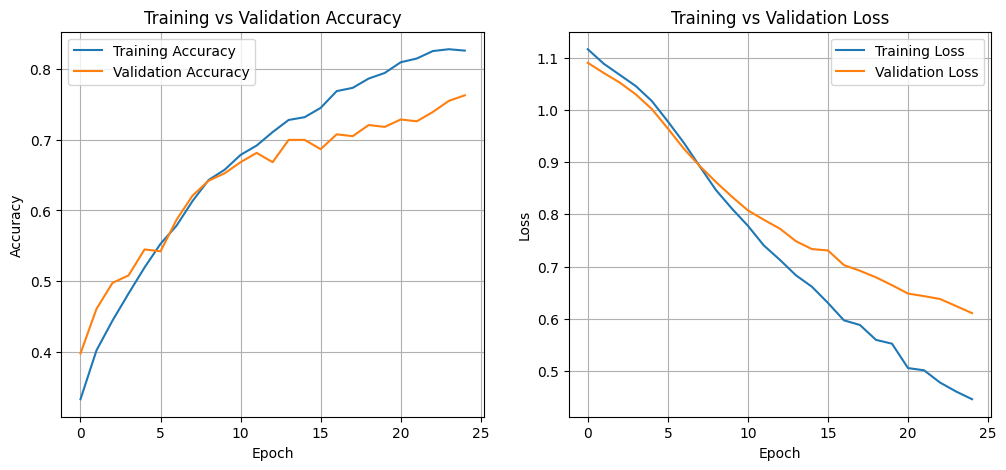

In [19]:
# Accuracy per epoch
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss per epoch
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()


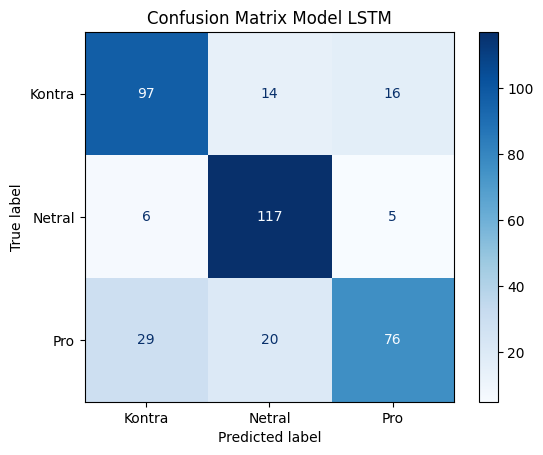

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

y_pred_prob = model.predict(X_val, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)


cm = confusion_matrix(y_val, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Kontra', 'Netral', 'Pro']
)
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix Model LSTM')
plt.show()


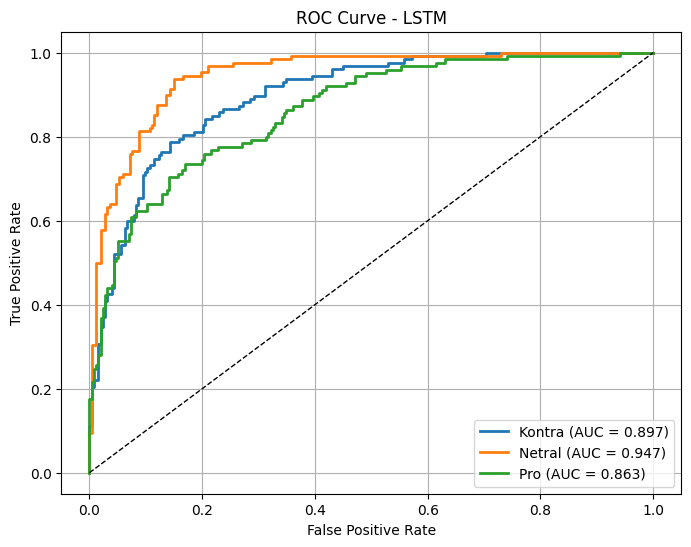

In [21]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_score = model.predict(X_val, verbose=0)

# Binarisasi label
y_val_bin = label_binarize(y_val, classes=[0,1,2])
labels = ['Kontra', 'Netral', 'Pro']

plt.figure(figsize=(8,6))

# Hitung ROC per kelas
for i, label in enumerate(labels):
    fpr, tpr, _ = roc_curve(y_val_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{label} (AUC = {roc_auc:.3f})')

# Garis diagonal
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - LSTM')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()



In [22]:
def predict_sentiment(text, model, tokenizer, maxlen):
    text_seq = tokenizer.texts_to_sequences([text])
    text_pad = pad_sequences(text_seq, maxlen=maxlen, padding='post', truncating='post')

    # prediksi probabilitas
    pred = model.predict(text_pad)
    label = np.argmax(pred, axis=1)[0]

    # mapping label ke kategori
    label_map = {
        0: "Kontra-Genocide",
        1: "Netral",
        2: "Pro-Genocide"
    }

    print(f"\nTeks: {text}")
    print(f"Prediksi: {label_map[label]} (label : {label})")
    print(f"Probabilitas: {pred[0]}")

    return label_map[label]

contoh_text = [
    "Israel is preventing humanitarian aid from entering Gaza, worsening the humanitarian crisis.",
    "Schools in Gaza have been destroyed, leaving young people already deprived of education due to COVID-19 and war, and facing a loss of future opportunities.",
    "Three Israeli hostages were handed over by Hamas in Gaza, while Palestinian prisoners were released as part of a ceasefire deal.",
    "A Chicago-based surgeon has treated patients with war-related injuries from Syria, Ukraine, and Gaza.",
    "Supporting Israel is described as supporting humanity, while opposing Hamas terrorism is also framed as a defense of human values.",
    "Hamas is the true terrorist."
]

for t in contoh_text:
    predict_sentiment(t, model, tokenizer, maxlen)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step

Teks: Israel is preventing humanitarian aid from entering Gaza, worsening the humanitarian crisis.
Prediksi: Kontra-Genocide (label : 0)
Probabilitas: [0.8409786  0.04809621 0.11092515]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step

Teks: Schools in Gaza have been destroyed, leaving young people already deprived of education due to COVID-19 and war, and facing a loss of future opportunities.
Prediksi: Kontra-Genocide (label : 0)
Probabilitas: [0.6248464  0.16418715 0.21096648]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step

Teks: Three Israeli hostages were handed over by Hamas in Gaza, while Palestinian prisoners were released as part of a ceasefire deal.
Prediksi: Netral (label : 1)
Probabilitas: [0.25263336 0.60223216 0.14513448]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

Teks: A Chicago-based surgeon has treated patients with war-related injuries from Syria, Ukraine, and Gaza.
Prediksi: Netral (label : 1)
Probabilitas: [0.27622437 0.5017953  0.22198027]
1/1 ━━━━━━

In [23]:
model.save('lstm_model.keras')
